# Receipt OCR with TrOCR — V2 (LoRA + Full Dataset)

**Improvements over V1:**
- LoRA (parameter-efficient fine-tuning) — trains ~2M instead of 333M params
- Full 30,185 training samples instead of 10,000 subset
- Larger batch size (16) thanks to LoRA memory savings
- Better Gradio inference using bounding boxes instead of sliding window

**Expected session time:** ~3.5h (fits within Kaggle 9h GPU limit)

In [ ]:
# Cell 1 — Install dependencies
!pip install transformers==4.40.0 peft==0.10.0 jiwer gradio -q

In [ ]:
# Cell 2 — Imports
import os
import random
import json
import time
import numpy as np
import torch
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from transformers import (
    VisionEncoderDecoderModel,
    TrOCRProcessor,
    get_linear_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType
from jiwer import cer, wer

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

In [ ]:
# Cell 3 — Config (all hyperparams in one place)
CONFIG = {
    # paths
    'base'       : '/kaggle/input/datasets/urbikn/sroie-datasetv2/SROIE2019',
    'save_dir'   : '/kaggle/working/crops',
    'output_dir' : '/kaggle/working/best_model_v2',

    # model
    'checkpoint' : 'microsoft/trocr-base-printed',
    'max_length' : 64,

    # LoRA
    'lora_r'         : 16,    # rank — higher = more capacity, more params
    'lora_alpha'     : 32,    # scaling factor (usually 2x rank)
    'lora_dropout'   : 0.1,

    # training
    'epochs'     : 5,
    'batch_size' : 16,        # larger than V1 (8) thanks to LoRA
    'lr'         : 5e-4,      # higher LR for LoRA (only small adapters trained)
    'weight_decay': 0.01,
    'grad_clip'  : 1.0,
    'warmup_ratio': 0.1,
    'seed'       : 42,
}

random.seed(CONFIG['seed'])
torch.manual_seed(CONFIG['seed'])
print('Config loaded.')
print(f"Training on FULL dataset | Epochs: {CONFIG['epochs']} | Batch: {CONFIG['batch_size']}")

## Phase 1 — Data Preparation

In [ ]:
# Cell 4 — Parse bounding boxes and crop text lines
def parse_box_file(box_path):
    samples = []
    with open(box_path, encoding='utf-8', errors='ignore') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(',', 8)
            if len(parts) < 9:
                continue
            coords = list(map(int, parts[:8]))
            text   = parts[8].strip()
            if not text:
                continue
            xs   = coords[0::2]
            ys   = coords[1::2]
            bbox = (min(xs), min(ys), max(xs), max(ys))
            samples.append((bbox, text))
    return samples


def build_manifest(split, save_subdir):
    img_dir = os.path.join(CONFIG['base'], split, 'img')
    box_dir = os.path.join(CONFIG['base'], split, 'box')
    out_dir = os.path.join(CONFIG['save_dir'], save_subdir)
    os.makedirs(out_dir, exist_ok=True)

    manifest = []
    ids = sorted([f[:-4] for f in os.listdir(img_dir) if f.endswith('.jpg')])

    for rid in ids:
        box_path = os.path.join(box_dir, rid + '.txt')
        if not os.path.exists(box_path):
            continue
        img   = Image.open(os.path.join(img_dir, rid + '.jpg')).convert('RGB')
        boxes = parse_box_file(box_path)
        for bbox, text in boxes:
            crop = img.crop(bbox)
            if crop.width < 10 or crop.height < 10:
                continue
            path = os.path.join(out_dir, f'{len(manifest)}.jpg')
            crop.save(path, quality=85)
            manifest.append({'img_path': path, 'text': text})
    return manifest


print('Building train manifest...')
train_manifest = build_manifest('train', 'train')
print('Building test manifest...')
test_manifest  = build_manifest('test',  'test')

# 90/10 train/val split
random.shuffle(train_manifest)
split_idx      = int(len(train_manifest) * 0.9)
val_manifest   = train_manifest[split_idx:]
train_manifest = train_manifest[:split_idx]

print(f'Train : {len(train_manifest)}')
print(f'Val   : {len(val_manifest)}')
print(f'Test  : {len(test_manifest)}')

In [ ]:
# Cell 5 — Dataset class + DataLoaders
processor = TrOCRProcessor.from_pretrained(CONFIG['checkpoint'])

class SROIEDataset(Dataset):
    def __init__(self, manifest):
        self.manifest = manifest

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        item = self.manifest[idx]
        img  = Image.open(item['img_path']).convert('RGB')
        pixel_values = processor(
            images=img, return_tensors='pt'
        ).pixel_values.squeeze()
        labels = processor.tokenizer(
            item['text'],
            padding='max_length',
            max_length=CONFIG['max_length'],
            truncation=True
        ).input_ids
        labels = [
            l if l != processor.tokenizer.pad_token_id else -100
            for l in labels
        ]
        return {
            'pixel_values': pixel_values,
            'labels'      : torch.tensor(labels)
        }


train_ds = SROIEDataset(train_manifest)
val_ds   = SROIEDataset(val_manifest)
test_ds  = SROIEDataset(test_manifest)

train_loader = DataLoader(
    train_ds, batch_size=CONFIG['batch_size'],
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader = DataLoader(
    val_ds, batch_size=CONFIG['batch_size'],
    shuffle=False, num_workers=2, pin_memory=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')

## Phase 2 — LoRA Setup

In [ ]:
# Cell 6 — Load base model
base_model = VisionEncoderDecoderModel.from_pretrained(CONFIG['checkpoint'])

# Required decoder config
base_model.config.decoder_start_token_id = processor.tokenizer.cls_token_id
base_model.config.pad_token_id           = processor.tokenizer.pad_token_id
base_model.config.vocab_size             = base_model.config.decoder.vocab_size

# Count params before LoRA
total_params = sum(p.numel() for p in base_model.parameters())
print(f'Base model parameters: {total_params:,}')

In [ ]:
# Cell 7 — Apply LoRA to the DECODER only
# LoRA targets the attention projection layers in the decoder
# The encoder (ViT) is frozen entirely — only decoder adapters are trained

lora_config = LoraConfig(
    r             = CONFIG['lora_r'],
    lora_alpha    = CONFIG['lora_alpha'],
    lora_dropout  = CONFIG['lora_dropout'],
    bias          = 'none',
    # Target the query and value projections in decoder attention layers
    target_modules = ['q_proj', 'v_proj'],
    # We apply LoRA to the decoder sub-model
    modules_to_save = [],
)

# Wrap only the decoder with LoRA
base_model.decoder = get_peft_model(base_model.decoder, lora_config)
base_model.to(device)

# Count trainable params after LoRA
trainable = sum(p.numel() for p in base_model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in base_model.parameters())
print(f'Trainable parameters : {trainable:,}  ({100*trainable/total:.2f}% of total)')
print(f'Frozen parameters    : {total - trainable:,}')
print(f'Total parameters     : {total:,}')
print()
print('V1 trained 333M params | V2 trains only ~2M params (LoRA)')

## Phase 3 — Training

In [ ]:
# Cell 8 — Optimizer and scheduler
# Only pass trainable parameters to optimizer
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, base_model.parameters()),
    lr=CONFIG['lr'],
    weight_decay=CONFIG['weight_decay']
)

total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'Total steps  : {total_steps}')
print(f'Warmup steps : {warmup_steps}')
print(f'LR           : {CONFIG["lr"]} (higher than V1 5e-5 — LoRA adapters converge faster)')

In [ ]:
# Cell 9 — Evaluation function
def evaluate(model, loader, split='val', max_batches=None):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for i, batch in enumerate(loader):
            if max_batches and i >= max_batches:
                break
            pixel_values = batch['pixel_values'].to(device)
            generated    = model.generate(
                pixel_values, max_new_tokens=CONFIG['max_length']
            )
            preds  = processor.tokenizer.batch_decode(
                generated, skip_special_tokens=True
            )
            labels = processor.tokenizer.batch_decode(
                [[l for l in lab.tolist() if l != -100]
                 for lab in batch['labels']],
                skip_special_tokens=True
            )
            all_preds  += preds
            all_labels += labels

    c = cer(all_labels, all_preds)
    w = wer(all_labels, all_preds)
    print(f'[{split}] CER: {c:.4f}  WER: {w:.4f}')
    return c, w

In [ ]:
# Cell 10 — Training loop
best_cer     = float('inf')
train_losses = []
val_cers     = []
val_wers     = []

print(f'Starting V2 training — {len(train_manifest)} samples, {CONFIG["epochs"]} epochs')
print(f'LoRA rank={CONFIG["lora_r"]}, alpha={CONFIG["lora_alpha"]}')
print('=' * 60)

for epoch in range(1, CONFIG['epochs'] + 1):
    base_model.train()
    epoch_loss = 0
    t0 = time.time()

    for step, batch in enumerate(train_loader):
        pixel_values = batch['pixel_values'].to(device)
        labels       = batch['labels'].to(device)

        outputs = base_model(pixel_values=pixel_values, labels=labels)
        loss    = outputs.loss

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(
            filter(lambda p: p.requires_grad, base_model.parameters()),
            CONFIG['grad_clip']
        )
        optimizer.step()
        scheduler.step()

        epoch_loss += loss.item()

        if step % 200 == 0:
            avg     = epoch_loss / (step + 1)
            elapsed = time.time() - t0
            print(f'  Epoch {epoch} | step {step}/{len(train_loader)} | loss {avg:.4f} | {elapsed:.0f}s')

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f'\nEpoch {epoch} done — avg loss: {avg_loss:.4f}')

    # evaluate on val (first 100 batches for speed during training)
    val_cer, val_wer_score = evaluate(base_model, val_loader, split='val', max_batches=100)
    val_cers.append(val_cer)
    val_wers.append(val_wer_score)

    if val_cer < best_cer:
        best_cer = val_cer
        # Save LoRA adapter weights only (much smaller than full model)
        os.makedirs(CONFIG['output_dir'], exist_ok=True)
        base_model.decoder.save_pretrained(CONFIG['output_dir'] + '/lora_adapter')
        # Also save full merged model for easy inference
        merged = base_model.decoder.merge_and_unload()
        base_model.decoder = merged
        base_model.save_pretrained(CONFIG['output_dir'] + '/merged')
        processor.save_pretrained(CONFIG['output_dir'] + '/merged')
        # Restore peft model for continued training
        base_model.decoder = get_peft_model(
            VisionEncoderDecoderModel.from_pretrained(
                CONFIG['output_dir'] + '/merged'
            ).decoder,
            lora_config
        ).to(device)
        print(f'  ✓ Best model saved (CER {best_cer:.4f})\n')

# Save training history
with open('/kaggle/working/training_history_v2.json', 'w') as f:
    json.dump({
        'train_losses': train_losses,
        'val_cers'    : val_cers,
        'val_wers'    : val_wers
    }, f)
print('History saved.')

## Phase 4 — Evaluation

In [ ]:
# Cell 11 — Load best merged model and run full test evaluation
from transformers import VisionEncoderDecoderModel, TrOCRProcessor

best_model = VisionEncoderDecoderModel.from_pretrained(
    CONFIG['output_dir'] + '/merged'
).to(device)
best_model.eval()
print('Best merged model loaded.')

# eval on 2000 test samples
random.seed(42)
test_subset  = random.sample(test_manifest, 2000)
test_ds_eval = SROIEDataset(test_subset)
test_loader  = DataLoader(
    test_ds_eval, batch_size=32,
    shuffle=False, num_workers=2
)

print('Running test evaluation...')
test_cer_score, test_wer_score = evaluate(best_model, test_loader, split='test')

In [ ]:
# Cell 12 — Full metrics
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        pixel_values = batch['pixel_values'].to(device)
        generated    = best_model.generate(pixel_values, max_new_tokens=64)
        preds  = processor.tokenizer.batch_decode(generated, skip_special_tokens=True)
        labels = processor.tokenizer.batch_decode(
            [[l for l in lab.tolist() if l != -100] for lab in batch['labels']],
            skip_special_tokens=True
        )
        all_preds  += preds
        all_labels += labels

# Exact match
exact = sum(1 for p,l in zip(all_preds, all_labels) if p.strip() == l.strip())

# Per-sample CER
from jiwer import cer as cer_single
sample_cers = []
for p, l in zip(all_preds, all_labels):
    if len(l) > 0:
        try: sample_cers.append(cer_single([l],[p]))
        except: pass
sample_cers = np.array(sample_cers)

print('=' * 55)
print('V2 RESULTS SUMMARY')
print('=' * 55)
print(f'Test CER            : {test_cer_score:.4f}  ({(1-test_cer_score)*100:.2f}% char acc)')
print(f'Test WER            : {test_wer_score:.4f}  ({(1-test_wer_score)*100:.2f}% word acc)')
print(f'Exact Match Rate    : {exact/len(all_labels)*100:.2f}%  ({exact}/{len(all_labels)})')
print(f'Median CER          : {np.median(sample_cers):.4f}')
print(f'% perfect lines     : {(sample_cers==0).mean()*100:.1f}%')
print(f'% CER < 0.1         : {(sample_cers<0.1).mean()*100:.1f}%')
print('-' * 55)
print('V1 BASELINE (for comparison)')
print('-' * 55)
print('Test CER  : 0.0203  (97.97% char acc)')
print('Test WER  : 0.0856  (91.44% word acc)')
print('Exact     : 88.65%')
print('=' * 55)

In [ ]:
# Cell 13 — Training curves comparison
import matplotlib.pyplot as plt

# Load V1 history if available
v1_path = '/kaggle/input/project-trocr/training_history.json'
v1 = None
if os.path.exists(v1_path):
    with open(v1_path) as f:
        v1 = json.load(f)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax = axes[0]
ax.plot(range(1, len(train_losses)+1), train_losses,
        marker='o', color='steelblue', linewidth=2, label='V2 (LoRA, 30k)')
if v1:
    ax.plot(range(1, len(v1['train_losses'])+1), v1['train_losses'],
            marker='s', color='gray', linewidth=1.5, linestyle='--', label='V1 (full FT, 10k)')
ax.set_title('Training Loss', fontsize=13)
ax.set_xlabel('Epoch'), ax.set_ylabel('Loss')
ax.legend(), ax.grid(alpha=0.3)

# CER
ax = axes[1]
ax.plot(range(1, len(val_cers)+1), val_cers,
        marker='o', color='coral', linewidth=2, label='V2 (LoRA, 30k)')
if v1:
    ax.plot(range(1, len(v1['val_cers'])+1), v1['val_cers'],
            marker='s', color='gray', linewidth=1.5, linestyle='--', label='V1 (full FT, 10k)')
ax.axhline(min(val_cers), linestyle=':', color='coral', alpha=0.5,
           label=f'V2 best: {min(val_cers):.4f}')
ax.set_title('Validation CER', fontsize=13)
ax.set_xlabel('Epoch'), ax.set_ylabel('CER (lower is better)')
ax.legend(), ax.grid(alpha=0.3)

plt.suptitle('V1 vs V2 Training Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_v2.png', dpi=150)
plt.show()
print(f'Best V2 Val CER: {min(val_cers):.4f}')

In [ ]:
# Cell 14 — Qualitative examples
print(f'{"LABEL":<40} {"V2 PREDICTION":<40}')
print('-' * 82)
for label, pred in zip(all_labels[:15], all_preds[:15]):
    match = '✓' if label.strip() == pred.strip() else '✗'
    print(f'{match} {label[:38]:<40} {pred[:38]:<40}')

In [ ]:
# Cell 15 — CER distribution plot
plt.figure(figsize=(10, 4))
plt.hist(sample_cers, bins=50, color='steelblue', edgecolor='white', alpha=0.85)
plt.axvline(np.mean(sample_cers), color='coral', linestyle='--',
            label=f'Mean: {np.mean(sample_cers):.3f}')
plt.axvline(np.median(sample_cers), color='green', linestyle='--',
            label=f'Median: {np.median(sample_cers):.3f}')
plt.title('V2 CER Distribution across Test Samples')
plt.xlabel('CER'), plt.ylabel('Count')
plt.legend(), plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/cer_distribution_v2.png', dpi=150)
plt.show()

## Phase 5 — Improved Gradio App

In [ ]:
# Cell 16 — Gradio app with bounding-box-guided inference
# Instead of blind sliding window, we use SROIE-style box detection:
# 1. Convert image to grayscale
# 2. Find horizontal text bands using row projection profile
# 3. Crop each detected band and pass to model
# This is much more accurate than fixed-stride sliding window

import gradio as gr
import numpy as np
from PIL import Image
import torch

def detect_text_bands(img_pil, min_height=15, merge_gap=8):
    """Detect horizontal text line bands using row projection."""
    gray  = np.array(img_pil.convert('L'))
    # Invert so text pixels are high
    inv   = 255 - gray
    # Row-wise mean — rows with text have higher values
    proj  = inv.mean(axis=1)
    thresh = proj.max() * 0.08

    # Find text row ranges
    in_band = False
    bands   = []
    start   = 0
    for i, val in enumerate(proj):
        if not in_band and val > thresh:
            in_band = True
            start   = i
        elif in_band and val <= thresh:
            in_band = False
            if i - start >= min_height:
                bands.append((start, i))
    if in_band and len(proj) - start >= min_height:
        bands.append((start, len(proj)))

    # Merge bands that are close together
    merged = []
    for band in bands:
        if merged and band[0] - merged[-1][1] <= merge_gap:
            merged[-1] = (merged[-1][0], band[1])
        else:
            merged.append(list(band))

    return merged


def predict_full_receipt(image):
    if image is None:
        return 'No image provided.'

    img = Image.fromarray(image).convert('RGB')
    w, h = img.size

    # Rescale large images
    if w > 1200:
        scale = 1200 / w
        img   = img.resize((int(w*scale), int(h*scale)))
        w, h  = img.size

    bands   = detect_text_bands(img)
    results = []

    for (y0, y1) in bands:
        pad  = 4
        crop = img.crop((0, max(0, y0-pad), w, min(h, y1+pad)))
        pv   = processor(images=crop, return_tensors='pt').pixel_values.to(device)
        with torch.no_grad():
            gen = best_model.generate(pv, max_new_tokens=64)
        text = processor.tokenizer.decode(gen[0], skip_special_tokens=True).strip()
        if text and len(text) > 1:
            results.append(text)

    return '\n'.join(results) if results else 'No text detected.'


app = gr.Interface(
    fn=predict_full_receipt,
    inputs=gr.Image(label='Upload receipt image'),
    outputs=gr.Textbox(label='Extracted text', lines=25),
    title='Receipt OCR — TrOCR V2 (LoRA)',
    description=(
        'Upload a full receipt image. '
        'V2 uses projection-based line detection instead of sliding window. '
        'Fine-tuned on 30,185 SROIE crops with LoRA.'
    ),
)

app.launch(share=True)

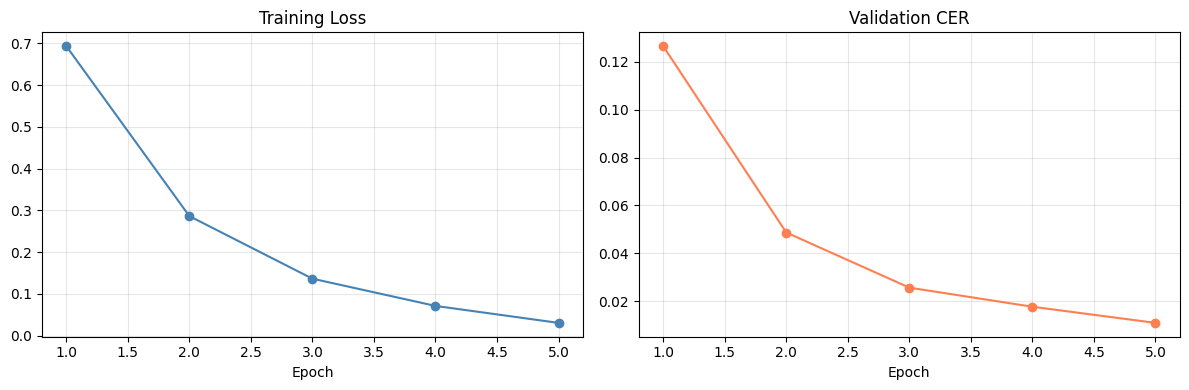

In [1]:
import json, matplotlib.pyplot as plt

with open("training_history_v2.json") as f:
    history = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history["train_losses"]) + 1)

ax1.plot(epochs, history["train_losses"], marker="o", color="steelblue")
ax1.set_title("Training Loss"), ax1.set_xlabel("Epoch"), ax1.grid(alpha=0.3)

ax2.plot(epochs, history["val_cers"], marker="o", color="coral")
ax2.set_title("Validation CER"), ax2.set_xlabel("Epoch"), ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curves2.png", dpi=150)
plt.show()